* 오라클 instant client 설치
  https://www.youtube.com/watch?v=yc3Jls86EoU
* LangGraph로 SQL AI에이전트 만들기 유튜브
  https://www.youtube.com/watch?v=e8PU42xBafo

In [2]:
# !python -m pip install -U langchain langchain-community langchain-openai
# !pip install oracledb sqlalchemy
# !python -m pip install -U langgraph

In [3]:
!python -V

Python 3.10.18


## OracleSQL connect

In [5]:
from urllib.parse import quote_plus
import os, oracledb
from langchain_community.utilities import SQLDatabase

IC_DIR = r"C:\Users\USER\Downloads\instantclient-basic-windows.x64-21.19.0.0.0dbru\instantclient_21_19"
os.add_dll_directory(IC_DIR)                    # DLL 검색 경로 보강
oracledb.init_oracle_client(lib_dir=IC_DIR)     # ← config_dir 주지 않습니다(TNS 비사용)

# XE는 SID이므로 sid="xe" (PDB라면 service_name="XEPDB1")
dsn = oracledb.makedsn("localhost", 1521, sid="xe")

uri = f"oracle+oracledb://LKDM:{quote_plus('1234')}@/?dsn={quote_plus(dsn)}"
db = SQLDatabase.from_uri(uri)

print(db.get_usable_table_names())

[]


In [6]:
import oracledb
try:
    print("client version:", oracledb.clientversion())  # Thick에서만 동작
    print("MODE: THICK")
except Exception:
    print("MODE: THIN")

client version: (21, 19, 0, 0, 0)
MODE: THICK


In [7]:
print(db.run("SELECT USER, SYS_CONTEXT('USERENV','CURRENT_SCHEMA') AS CURRENT_SCHEMA FROM dual"))
print(db.run("SELECT table_name FROM user_tables ORDER BY table_name"))

[('LKDM', 'LKDM')]
[('AFTER_SERVICE',), ('AREA_CD',), ('AS_CD',), ('BILL_OF_MATERIAL',), ('CUSTOMER',), ('DAY',), ('DEPARTMENT',), ('EMPLOYEE',), ('EMP_FAMILY',), ('FAMILY_CD',), ('HOUSE_CD',), ('INVENTORY',), ('JOB_DUTY_CD',), ('JOB_POSITION',), ('MAJOR_CD',), ('MATERIAL_IN_OUT',), ('MEDICAL_INSURANCE',), ('MONTH_PRODUCT_IN_OUT',), ('NATIONAL_PENSION',), ('OVERTIME',), ('PART',), ('PRODUCT',), ('PRODUCT_IN_OUT_AMOUNT_PRICE',), ('RELIGION_CD',), ('SALARY',), ('SALARY_DETAIL',), ('SCHOOL_CD',), ('VACATION',), ('VENDOR',), ('WORK_CD',), ('ZIP_CD',)]


In [8]:
rows_str = db.run("SELECT table_name FROM user_tables ORDER BY table_name")
rows_str

"[('AFTER_SERVICE',), ('AREA_CD',), ('AS_CD',), ('BILL_OF_MATERIAL',), ('CUSTOMER',), ('DAY',), ('DEPARTMENT',), ('EMPLOYEE',), ('EMP_FAMILY',), ('FAMILY_CD',), ('HOUSE_CD',), ('INVENTORY',), ('JOB_DUTY_CD',), ('JOB_POSITION',), ('MAJOR_CD',), ('MATERIAL_IN_OUT',), ('MEDICAL_INSURANCE',), ('MONTH_PRODUCT_IN_OUT',), ('NATIONAL_PENSION',), ('OVERTIME',), ('PART',), ('PRODUCT',), ('PRODUCT_IN_OUT_AMOUNT_PRICE',), ('RELIGION_CD',), ('SALARY',), ('SALARY_DETAIL',), ('SCHOOL_CD',), ('VACATION',), ('VENDOR',), ('WORK_CD',), ('ZIP_CD',)]"

In [9]:
import ast
rows = ast.literal_eval(rows_str)     # -> [('AFTER_SERVICE',), ('AREA_CD',), ...] (진짜 list of tuples)
tables = [r[0] for r in rows]         # -> ['AFTER_SERVICE', 'AREA_CD', ...]
print(type(rows), len(rows))
print(tables[:10])

<class 'list'> 31
['AFTER_SERVICE', 'AREA_CD', 'AS_CD', 'BILL_OF_MATERIAL', 'CUSTOMER', 'DAY', 'DEPARTMENT', 'EMPLOYEE', 'EMP_FAMILY', 'FAMILY_CD']


In [10]:
# 행 개수 보기
print(db.run("SELECT COUNT(*) FROM EMPLOYEE"))
print(db.run("SELECT COUNT(*) FROM DEPARTMENT"))

# 최근 10건
db.run("SELECT * FROM EMPLOYEE WHERE ROWNUM <= 5")

[(10,)]
[(5,)]


"[('98001', '7208221999999', '이공명', 'S1', None, 'A001', datetime.datetime(1997, 10, 25, 0, 0), '1', None, '05', '435047', '경기도 군포시 궁내동 주공아파트', 'N', None, '0343-399-xxxx', '012-1039-xxxx', None, None, '100', 'lkdm@chollian.net', 'Hitel, Chollian ID => LKDM', 'www.lkdm.co.kr', None, None, datetime.datetime(1972, 8, 22, 0, 0), '1', '05', '컴퓨터랑 놀기, 농구', None, Decimal('0.4'), Decimal('0.2'), 'N', 'B', 'RH+', Decimal('179'), Decimal('67'), None, '1', '01'), ('98002', '7502281999999', '이대명', 'S2', '01', 'B001', datetime.datetime(1997, 10, 25, 0, 0), '1', None, '06', '435047', '경기도 군포시 궁내동', 'N', None, '0343-395-xxxx', '017-754-xxxx', None, None, None, 'lkdm@chollian.net', 'Hitel, Chollian ID => LKDM', 'www.lkdm.co.kr', 950, None, datetime.datetime(1975, 2, 28, 0, 0), '1', '05', '역사파고들기', '힘..', Decimal('1'), Decimal('1'), 'N', 'O', 'RH+', Decimal('181'), Decimal('80'), None, '1', '01'), ('98003', '7407081999999', '문광헌', 'M1', '01', 'D001', datetime.datetime(1997, 12, 3, 0, 0), '1', None, '06'

In [11]:
from langchain_community.utilities import sql_database as lc_sql

# db2 = lc_sql.SQLDatabase(db._engine, schema="LKDM")
db2 = lc_sql.SQLDatabase(
    db._engine,
    schema="LKDM",
    sample_rows_in_table_info=0,   # ★ 핵심
)

# 3) 내부 속성 강제 주입(핵심 핫픽스)
db2._all_tables = set(tables)        # 리플렉션 대신 우리가 수집한 목록 사용
db2._include_tables = set()          # 제한 안 둘 거면 빈 집합 유지
db2._ignore_tables = set()           # 무시 없음

print("usable:", db2.get_usable_table_names())  # 이제 비면 안 됩니다. 

usable: ['AFTER_SERVICE', 'AREA_CD', 'AS_CD', 'BILL_OF_MATERIAL', 'CUSTOMER', 'DAY', 'DEPARTMENT', 'EMPLOYEE', 'EMP_FAMILY', 'FAMILY_CD', 'HOUSE_CD', 'INVENTORY', 'JOB_DUTY_CD', 'JOB_POSITION', 'MAJOR_CD', 'MATERIAL_IN_OUT', 'MEDICAL_INSURANCE', 'MONTH_PRODUCT_IN_OUT', 'NATIONAL_PENSION', 'OVERTIME', 'PART', 'PRODUCT', 'PRODUCT_IN_OUT_AMOUNT_PRICE', 'RELIGION_CD', 'SALARY', 'SALARY_DETAIL', 'SCHOOL_CD', 'VACATION', 'VENDOR', 'WORK_CD', 'ZIP_CD']


## Utility functions

In [13]:
from typing import Any
from langchain_core.messages import ToolMessage
from langchain_core.runnables import RunnableLambda, RunnableWithFallbacks
from langgraph.prebuilt import ToolNode

# → 에이전트가 도구(툴)를 실행하다가 에러가 나면, 에러를 잡아 handle_tool_error로 넘겨 정리된 형태로 에이전트(모델)에게 전달하게 만드는 “안전망”을 장착
def create_tool_node_with_fallback(tools:list) -> RunnableWithFallbacks[Any, dict]:
    """
    Create a ToolNode with a fallback to handle errors and surface them to the agent.
    """
    return ToolNode(tools).with_fallbacks(
        [RunnableLambda(handle_tool_error)], exception_key="error"
    )

def handle_tool_error(state) -> dict:
    error = state.get("error")
    tool_calls = state["messages"][-1].tool_calls
    return {
        "messages": [
            ToolMessage(
                content=f"Error: {repr(error)}\n please fix your mistakes.",
                tool_call_id=tc["id"],
            )
            for tc in tool_calls
        ]
    }

### gpt5 버전
# def handle_tool_error(state: dict) -> dict:
#     err = state.get("error")  # 예외 객체
#     # 직전 툴 콜의 tool_call_id를 보존하면 에이전트가 맥락을 이해하기 쉽습니다.
#     last_msg = state.get("messages", [])[-1] if state.get("messages") else None
#     tool_call_id = getattr(getattr(last_msg, "additional_kwargs", {}), "get", lambda *_: None)("tool_call_id")

#     human_safe = f"ToolError: {type(err).__name__} - {err}"
#     # 에이전트가 '툴 응답'으로 인식할 수 있도록 ToolMessage에 담아 반환
#     return {
#         "messages": [
#             ToolMessage(
#                 content=human_safe,
#                 name=getattr(last_msg, "name", "unknown_tool"),
#                 tool_call_id=tool_call_id,
#             )
#         ]
#     }

## Define tools for the agent
* 아래의 3개의 툴 정의
  - list_tables_tool: 데이터베이스에서 사용 가능한 테이블 목록을 가져옴
  - get_schema_tool: 특정 테이블의 DDL 정의 구조를 보여줌
  - db_query_tool: 문자열 SQL문이 들어오면 실행하고 결과를 반환

#### ***** 1차 실패 : get_schema_tool.invoke({"table_names": "AREA_CD"}) 실패 *****

In [16]:
from langchain_community.agent_toolkits import SQLDatabaseToolkit
from langchain_openai import ChatOpenAI

toolkit = SQLDatabaseToolkit(db=db2, llm=ChatOpenAI(model="gpt-4o-mini"))
tools = toolkit.get_tools()

tools

[QuerySQLDatabaseTool(description="Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.", db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x000001D938742680>),
 InfoSQLDatabaseTool(description='Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3', db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x000001D938742680>),
 ListSQLDatabaseTool(db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x000001D938742680>),
 QuerySQLCheckerTool(description='Use this tool to 

In [17]:
[t.name for t in tools]

['sql_db_query', 'sql_db_schema', 'sql_db_list_tables', 'sql_db_query_checker']

In [18]:
list_tables_tool = next(tool for tool in tools if tool.name == "sql_db_list_tables")
get_schema_tool = next(tool for tool in tools if tool.name == "sql_db_schema")

list_tables_tool.invoke("")

'AFTER_SERVICE, AREA_CD, AS_CD, BILL_OF_MATERIAL, CUSTOMER, DAY, DEPARTMENT, EMPLOYEE, EMP_FAMILY, FAMILY_CD, HOUSE_CD, INVENTORY, JOB_DUTY_CD, JOB_POSITION, MAJOR_CD, MATERIAL_IN_OUT, MEDICAL_INSURANCE, MONTH_PRODUCT_IN_OUT, NATIONAL_PENSION, OVERTIME, PART, PRODUCT, PRODUCT_IN_OUT_AMOUNT_PRICE, RELIGION_CD, SALARY, SALARY_DETAIL, SCHOOL_CD, VACATION, VENDOR, WORK_CD, ZIP_CD'

In [19]:
get_schema_tool

InfoSQLDatabaseTool(description='Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3', db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x000001D938742680>)

In [20]:
schema_txt = get_schema_tool.invoke({"table_names": "AREA_CD"})
print(schema_txt)

InvalidRequestError: Could not reflect: requested table(s) not available in Engine(oracle+oracledb://LKDM:***@/?dsn=%28DESCRIPTION%3D%28ADDRESS%3D%28PROTOCOL%3DTCP%29%28HOST%3Dlocalhost%29%28PORT%3D1521%29%29%28CONNECT_DATA%3D%28SID%3Dxe%29%29%29) schema 'LKDM': (AREA_CD)

#### ***** 2차 시도 성공 코드 *****
- **리플렉션(스키마 인트로스펙션)**은 SQLAlchemy가 데이터베이스에 물어봐서 테이블 목록, 컬럼 이름/타입, 제약조건 같은 스키마 정보를 자동으로 읽어오는 과정이에요.
- 내부적으로 Inspector.get_table_names(), Inspector.get_columns() 등을 호출하고,
- 오라클에선 ALL_TABLES, ALL_TAB_COLUMNS 같은 데이터 사전 뷰를 조회해서 정보를 가져옵니다.
- 이게 잘 되면 MetaData.reflect(...)로 메타데이터 객체가 자동 채워지죠.
- 하지만 환경/권한/드라이버 이슈(특히 오라클)로 리플렉션이 빈 목록을 돌려주거나 실패하는 일이 있어요.
- 아래의 코드 한줄 요약
- 데이터 사전에서 직접 컬럼 정보를 조회
- 그걸로 MetaData에 테이블/컬럼을 수동으로 정의
- SQLDatabase에 해당 MetaData를 주입하고, 샘플 로우 조회는 OFF
- 내부 검증용 테이블 집합도 직접 세팅

In [47]:
from sqlalchemy import MetaData, Table, Column, text
from sqlalchemy import String, Numeric, Date, DateTime, LargeBinary
from langchain_community.utilities import sql_database as lc_sql
from langchain_community.agent_toolkits import SQLDatabaseToolkit
from langchain_openai import ChatOpenAI

OWNER = "LKDM"
TABLES = tables  # ← 여러 개

def oracle_to_sqla_type(dt, L, P, S):
    dt = (dt or "").upper()
    if dt in ("VARCHAR2", "NVARCHAR2", "CHAR", "NCHAR"):
        return String(int(L) if L else None)
    if dt == "NUMBER":
        if P is not None and S is not None:
            return Numeric(int(P), int(S))
        elif P is not None:
            return Numeric(int(P))
        else:
            return Numeric()
    if dt == "DATE":
        return Date()
    if dt.startswith("TIMESTAMP"):
        return DateTime()
    if dt in ("RAW", "BLOB"):
        return LargeBinary()
    # 기타 타입은 일단 길이 기반 String으로 처리
    return String(int(L) if L else None)

# 1) 데이터사전에서 컬럼 읽어서 메타데이터에 '여러 테이블' 등록
md = MetaData()
present = []  # 실제로 컬럼을 읽어온(존재하는) 테이블만 담음
with db2._engine.connect() as conn:
    for t in TABLES:
        rows = conn.execute(text("""
            SELECT column_id, column_name, data_type, data_length,
                   data_precision, data_scale, nullable
            FROM all_tab_columns
            WHERE owner=:o AND table_name=:t
            ORDER BY column_id
        """), {"o": OWNER, "t": t}).fetchall()
        if not rows:
            continue
        cols = []
        for _, name, dt, L, P, S, nullable in rows:
            cols.append(Column(str(name), oracle_to_sqla_type(dt, L, P, S),
                               nullable=(nullable == "Y")))
        Table(t, md, *cols, schema=OWNER)  # ★ reflect 안 쓰고 직접 정의
        present.append(t)

# 2) 샘플 로우는 끄고(SQLDatabase가 DUAL 실수 안 하게) + 메타데이터 주입
db_fix = lc_sql.SQLDatabase(
    db2._engine,
    schema=OWNER,
    metadata=md,
    sample_rows_in_table_info=0,  # ★ 중요: ORA-00936 방지
)

# 3) 내부 테이블 집합을 우리가 넣은 목록으로 설정(존재 검증 통과)
db_fix._all_tables = set(present)
db_fix._include_tables = set()
db_fix._ignore_tables = set()

# 4) 툴킷 재생성 후 호출 (여러 테이블은 콤마 구분 문자열로!)
toolkit = SQLDatabaseToolkit(db=db_fix, llm=ChatOpenAI(model="gpt-4o-mini"))
tools = toolkit.get_tools()
# by = {t.name: t for t in tools}
list_tables_tool = next(tool for tool in tools if tool.name == "sql_db_list_tables")
get_schema_tool = next(tool for tool in tools if tool.name == "sql_db_schema")

# 6) 이제 정상 동작 (반드시 dict로 호출!)
print(list_tables_tool.invoke(""))
print(get_schema_tool.invoke({"table_names": "AREA_CD"}))


AFTER_SERVICE, AREA_CD, AS_CD, BILL_OF_MATERIAL, CUSTOMER, DAY, DEPARTMENT, EMPLOYEE, EMP_FAMILY, FAMILY_CD, HOUSE_CD, INVENTORY, JOB_DUTY_CD, JOB_POSITION, MAJOR_CD, MATERIAL_IN_OUT, MEDICAL_INSURANCE, MONTH_PRODUCT_IN_OUT, NATIONAL_PENSION, OVERTIME, PART, PRODUCT, PRODUCT_IN_OUT_AMOUNT_PRICE, RELIGION_CD, SALARY, SALARY_DETAIL, SCHOOL_CD, VACATION, VENDOR, WORK_CD, ZIP_CD

CREATE TABLE "LKDM"."AREA_CD" (
	"AREA_CODE" VARCHAR2(2 CHAR) NOT NULL, 
	"AREA_NAME" VARCHAR2(20 CHAR)
)


In [49]:
print(get_schema_tool.invoke({"table_names": "EMPLOYEE"}))


CREATE TABLE "LKDM"."EMPLOYEE" (
	"EMPNO" VARCHAR2(5 CHAR) NOT NULL, 
	"JUMIN_NO" VARCHAR2(13 CHAR), 
	"EMP_NAME" VARCHAR2(20 CHAR), 
	"JIKGB_CODE" VARCHAR2(2 CHAR), 
	"JIKCH_CODE" VARCHAR2(2 CHAR), 
	"DEPT_CODE" VARCHAR2(4 CHAR), 
	"IBSA_DATE" DATE, 
	"HT_CODE" VARCHAR2(1 CHAR), 
	"HT_DATE" DATE, 
	"SCHOOL_CODE" VARCHAR2(2 CHAR), 
	"ZIP_CODE" VARCHAR2(6 CHAR), 
	"ADDRESS" VARCHAR2(70 CHAR), 
	"MARRY_CODE" VARCHAR2(1 CHAR), 
	"MARRY_DATE" DATE, 
	"TEL" VARCHAR2(15 CHAR), 
	"TEL_1" VARCHAR2(15 CHAR), 
	"TEL_2" VARCHAR2(15 CHAR), 
	"TEL_3" VARCHAR2(15 CHAR), 
	"INTERPHONE" VARCHAR2(5 CHAR), 
	"INTERNET_1" VARCHAR2(30 CHAR), 
	"INTERNET_2" VARCHAR2(30 CHAR), 
	"INTERNET_3" VARCHAR2(30 CHAR), 
	"TOEIC_MARK" NUMERIC(4, 0), 
	"JPT_MARK" NUMERIC(4, 0), 
	"BIRTH_DATE" DATE, 
	"BIRTH_CODE" VARCHAR2(1 CHAR), 
	"RELIGION_CD" VARCHAR2(4 CHAR), 
	"HOBBY" VARCHAR2(40 CHAR), 
	"WELL" VARCHAR2(40 CHAR), 
	"EYE_L" NUMERIC(2, 1), 
	"EYE_R" NUMERIC(2, 1), 
	"COLOR_CODE" VARCHAR2(1 CHAR), 
	"BLOOD" VARCH

In [118]:
from langchain_core.tools import tool

# @tool
# def db_query_tool(query: str) -> str:
#     """
#     Execute a SQL query against the database and get back the result.
#     If the query is not correct, an error message will be returned.
#     If an error is returned, rewrite the query, check the query, and try again.
#     """
#     result = db.run_no_throw(query)
#     if not result:
#         return "Error: Query failed. please rewrite your query and try again."
#     return result

# ### run_no_throw()는 항상 문자열을 돌려준다는 점이 포인트예요.
# #     run() : 쿼리 실행 중 에러가 나면 예외를 발생시킴.
# #     run_no_throw() : 쿼리 실행 중 에러가 나면 예외를 던지지 않고
# #     "Error: (오라클에러...) ORA-... [SQL: ...]" 같은 에러 문자열을 반환.
# #     성공 시에도 문자열을 반환합니다.

### gpt 버전 !!
# 모델이 ToolMessage에서
        # Error: ...면 쿼리 수정
        # Empty: 0 rows면 스키마 확인/검색 범위 수정으로 전략 전환
        # JSON이면 정상 결과로 인식
@tool
def db_query_tool(query: str) -> str:
    """
    Execute a READ-ONLY SQL query (Oracle).
    - Strip trailing semicolons to avoid ORA-00911.
    - Return explicit JSON on success: {"rows":[...], "columns":[...], "rowcount":N}
    - Return explicit 'Error: ...' text on failure.
    - Return explicit 'Empty: 0 rows' on empty results (루프 방지에 중요!)
    """

    import re, json
    if not query:
        return "Error: Empty query."

    sql = query.strip()
    if sql.endswith(";"):
        sql = sql[:-1].rstrip()

    if re.search(r"\b(INSERT|UPDATE|DELETE|DROP|ALTER|TRUNCATE|MERGE|CREATE)\b", sql, re.I):
        return "Error: Only read-only SELECT queries are allowed."

    try:
        result = db.run_no_throw(sql)
    except Exception as e:
        return f"Error: {str(e)}"

    # ✅ None/빈 문자열 → 에러가 아니라 'Empty'
    if result is None or result == "":
        return "Empty: 0 rows"

    rows, cols = None, None
    if isinstance(result, dict):
        if result.get("error"):
            return f"Error: {result['error']}"
        rows = result.get("rows") or result.get("data") or result.get("result")
        cols = result.get("columns") or result.get("cols")
    elif isinstance(result, (list, tuple)):
        rows = result
    else:
        try:
            return json.dumps(result, ensure_ascii=False, default=str)
        except Exception:
            return str(result)

    if rows is None:
        return "Empty: 0 rows"

    if isinstance(rows, (list, tuple)) and len(rows) == 0:
        return "Empty: 0 rows"

    return json.dumps({"rows": rows, "columns": cols,
                       "rowcount": (len(rows) if hasattr(rows, "__len__") else None)},
                      ensure_ascii=False, default=str)

print(db_query_tool.invoke("select * from AREA_CD WHERE ROWNUM <= 5"))

"[('01', '서울'), ('02', '경기도'), ('03', '강원도'), ('04', '충청도'), ('05', '전라도')]"


* 노드 정의
  - LLM이 작성한 쿼리문에 대해 오류 검사가능한 프롬프트

In [120]:
from langchain_core.prompts import ChatPromptTemplate

# 모델에게 “SQL을 실행하기 전에 이런 실수들(UNION/UNION ALL, BETWEEN 경계, 타입 캐스팅, 따옴표 등)을 체크하고
# 필요하면 고쳐라. 문제가 없으면 원문을 그대로 두어라.”고 지시
query_check_system = """You are a SQL expert with a strong attention to detail.
Double check the SQL query for common mistakes, including:
- Using NOT IN with NULL values
- Using UNION when UNION ALL should have been used
- Using BETWEEN for exclusive ranges
- Data type mismatch in predicates
- Properly quoting identifiers
- Using the correct number of arguments for functions
- Casting to the correct data type
- Using the proper columns for joins

If there are any of the above mistakes, rewrite the query. If there are no mistakes, just reproduce the original query.

You will call the appropriate tool to execute the query after running this check.
"""

query_check_prompt = ChatPromptTemplate.from_messages(
    [("system", query_check_system), ("placeholder", "{messages}")]
)
# query_check는 LLM이 텍스트로 검수/수정만 하고, 그다음 툴을 호출하라고 지시
# 이때 쓰는 “툴 이름”이 db_query_tool로 같은 함수를 가리키죠
query_check = query_check_prompt | ChatOpenAI(model="gpt-4o-mini", temperature=0).bind_tools(
    [db_query_tool], tool_choice="required"   # tool_choice="required"로 툴 호출을 반드시 하도록 강제
)  

query_check.invoke({"messages":[("user", "select * from AREA_CD WHERE ROWNUM <= 5")]})

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_YC4x9VQJ2ZlIBQhn3MHkpo0z', 'function': {'arguments': '{"query":"select * from AREA_CD WHERE ROWNUM <= 5"}', 'name': 'db_query_tool'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 259, 'total_tokens': 285, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_560af6e559', 'id': 'chatcmpl-C8dqIPOOGGFfXuO9PN73KorwygCBl', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--24366ebc-ae55-4923-bfd9-5b63ea07835b-0', tool_calls=[{'name': 'db_query_tool', 'args': {'query': 'select * from AREA_CD WHERE ROWNUM <= 5'}, 'id': 'call_YC4x9VQJ2ZlIBQhn3MHkpo0z', 'type': 'tool_call'}], usage_metadata={'input_tokens': 

## Define the workflow
- 먼저 list_tables_tool을 강제 호출하여 데이터베이스에서 사용 가능한 테이블 목록을 가져온 후, 순차적으로 단계 수행

In [ ]:
##### gpt안 실패 

# from typing import Annotated, Literal
# from langchain_core.messages import AIMessage
# from langchain_openai import ChatOpenAI
# from pydantic import BaseModel, Field
# from typing_extensions import TypedDict
# from langgraph.graph import END, StateGraph, START
# from langgraph.graph.message import AnyMessage, add_messages

# class State(TypedDict):
#     messages: Annotated[list[AnyMessage], add_messages]

# workflow = StateGraph(State)

# # 툴의 입력 스키마를 정의하는 Pydantic 모델
# # 에이전트에서 “최종 답 제출”을 도구 호출(tool call) 로 표현하게 만들 때 사용 
# class SubmitFinalAnswer(BaseModel):   
#     """Submit the final answer to the user based on the query results."""
#     final_answer: str = Field(..., description="The final answer to the user")
#         # 모델이 여러 툴(예: SQL 실행)을 쓰다 이제 답을 확정하면,
#         # SubmitFinalAnswer 라는 툴을 호출하면서 {"final_answer": "..."}
#         # 형태의 구조화된 페이로드를 내보내게 하려는 것.
#         # 즉, “끝났어. 유저에게 이 문자열을 보여줘!”라는 신호 역할

# query_gen_system = """You are a SQL expert with a strong attention to detail.
# Given an input question, WRITE a syntactically correct SQL query.
# To run a query, CALL the tool `db_query_tool` with the SQL you just wrote.
# Read the tool result, then if you can answer, CALL `SubmitFinalAnswer` with `final_answer`.
# If the result is empty or errors, refine the SQL and CALL `db_query_tool` again.
# Limit to at most 5 rows unless the user asked for more.
# Select only relevant columns. Never perform DML (INSERT/UPDATE/DELETE/DROP).
# """

# query_gen_prompt = ChatPromptTemplate.from_messages(
#     [("system", query_gen_system), ("placeholder", "{messages}")]
# )
# query_gen = query_gen_prompt | ChatOpenAI(model="gpt-4o-mini", temperature=0).bind_tools(
#     [SubmitFinalAnswer, db_query_tool, get_schema_tool, list_tables_tool]
# )

# def query_gen_node(state: State):
#     msg = query_gen.invoke(state)
#     return {"messages": [msg]}

# def should_continue(state: State) -> Literal[END, "tools", "query_gen"]:
#     last = state["messages"][-1]

#     # assistant가 툴 호출했으면
#     if isinstance(last, AIMessage) and getattr(last, "tool_calls", None):
#         # 최종 제출이면 종료
#         if any(tc["name"] == "SubmitFinalAnswer" for tc in last.tool_calls):
#             return END
#         # 그 외 모든 툴콜은 단일 툴 노드로 라우팅
#         return "tools"

#     # 툴 결과면 모델로 돌아가 읽게
#     if isinstance(last, ToolMessage):
#         return "query_gen"

#     # 그 외는 계속 모델
#     return "query_gen"

# # 단일 툴 실행 노드
# workflow.add_node(
#     "tools",
#     create_tool_node_with_fallback([db_query_tool, get_schema_tool, list_tables_tool])
# )
# workflow.add_node("query_gen", query_gen_node)

# workflow.add_edge(START, "query_gen")
# workflow.add_conditional_edges("query_gen", should_continue)
# workflow.add_edge("tools", "query_gen")

# app = workflow.compile()

In [ ]:
##### 1안 실패 -> final_answer: I don't have enough information.
### 원인
# 1. 실행 데이터가 없음
# 2. 프롬프트/툴 바인딩이 “조기 Submit” 쪽으로 기울어 있음
#    query_gen에는 SubmitFinalAnswer만 바인딩했고, DB 실행툴(db_query_tool)을 못 부릅니다.
#    프롬프트도 “SubmitFinalAnswer 외에는 다른 툴 금지”라 모델이 “모르겠다 → SubmitFinalAnswer”을 고르기 쉬워요
# 3. 종료 조건이 너무 느슨함
#    should_continue가 SubmitFinalAnswer만 보면 END로 가고, 이전에 실제 쿼리를 한 번이라도 실행했는지는 체크하지 않아요.



# from typing import Annotated, Literal
# from langchain_core.messages import AIMessage
# from langchain_openai import ChatOpenAI
# from pydantic import BaseModel, Field
# from typing_extensions import TypedDict
# from langgraph.graph import END, StateGraph, START
# from langgraph.graph.message import AnyMessage, add_messages

# class State(TypedDict):
#     messages: Annotated[list[AnyMessage], add_messages]

# workflow = StateGraph(State)

# def first_tool_call(state: State) -> dict[str, list[AIMessage]]:
#     return {
#         "messages":[
#             AIMessage(
#                 content="",
#                 tool_calls=[
#                     {
#                         "name": "sql_db_list_tables",
#                         "args": {},
#                         "id": "tool_abcd123",
#                     }
#                 ],
#             )
#         ]
#     }

# def model_check_query(state: State) -> dict[str, list[AIMessage]]:
#     """
#     Use this tool to double-check if your query is correct before executing it.
#     """
#     return {"messages":[query_check.invoke({"messages": [state["messages"][-1]]})]}

# workflow.add_node("first_tool_call", first_tool_call)
# workflow.add_node(
#     "list_tables_tool", create_tool_node_with_fallback([list_tables_tool])  # ToolNode 생성해서 바로 workflow에 가가
# )
# workflow.add_node(
#     "get_schema_tool", create_tool_node_with_fallback([get_schema_tool])  # ToolNode 생성해서 바로 workflow에 가가
# )

# # 대화 메시지를 받으면, 필요하다고 판단할 때 get_schema_tool을 호출 지시 
# # 대화를 받아 관련있는 테이블을 판단하여 get_schema_tool을 호출 지시
# # 자기 혼자 DB를 조회하진 않고, 툴 호출 지시를 담은 메시지를 반환
# model_get_schema = ChatOpenAI(model="gpt-4o-mini", temperature=0).bind_tools([get_schema_tool])

# workflow.add_node(
#     "model_get_schema",
#     lambda state: {                # 람다문법 -> lambda <파라미터들>: <하나의 표현식>
#         "messages": [model_get_schema.invoke(state["messages"])],
#     },
# )
# ### 위 코드와 같은 뜻의 가독성 버전 (참고)!!
# # def run_model_get_schema(state):
# #     history = state["messages"]                 # 지금까지의 대화
# #     reply = model_get_schema.invoke(history)    # 모델에게 물어봐서 답 1개 받기
# #     return {"messages": [reply]}                # 답 1개를 메시지 목록에 추가

# # workflow.add_node("model_get_schema", run_model_get_schema)

# # 툴의 입력 스키마를 정의하는 Pydantic 모델
# # 에이전트에서 “최종 답 제출”을 도구 호출(tool call) 로 표현하게 만들 때 사용 
# class SubmitFinalAnswer(BaseModel):   
#     """Submit the final answer to the user based on the query results."""
#     final_answer: str = Field(..., description="The final answer to the user")
#         # 모델이 여러 툴(예: SQL 실행)을 쓰다 이제 답을 확정하면,
#         # SubmitFinalAnswer 라는 툴을 호출하면서 {"final_answer": "..."}
#         # 형태의 구조화된 페이로드를 내보내게 하려는 것.
#         # 즉, “끝났어. 유저에게 이 문자열을 보여줘!”라는 신호 역할

# ### 프롬프트 오류:
#     # 프롬프트에 “SubmitFinalAnswer 외에는 아무 도구도 호출하지 말라”고 써두셨습니다.
#     # 그런데 그래프는 execute_query 노드에서 DB 쿼리 도구가 호출되길 전제로 엣지를 묶어놨어요.
#     # → 모델은 DB 도구를 절대 부르면 안 되니(금지), execute_query는 실행 트리거가 없고, 결과가 없으니 모델은 또 쿼리만 출력…, 무한 루프.

# ### 위의 오류로 인해 아래와 같이 gpt 수정버전으로 수정함 
# query_gen_system = """You are a SQL expert with a strong attention to detail.
# Given an input question, output a syntactically correct SQL query to run, then look at the results of the query and return the answer.
# DO NOT call any tool besides SubmitFinalAnswer to submit the final answer.
# When generating the query:
# Output the SQL query that answers the input question without a tool call.
# Unless the user specifies a specific number of examples they wish to obtain, always limit your query to at most 5 results.
# You can order the results by a relevant column to return the most interesting examples in the database.
# Never query for all the columns from a specific table, only ask for the relevant columns given the question.
# If you get an error while executing a query, rewrite the query and try again.
# If you get an empty result set, you should try to rewrite the query to get a non-empty result set.
# NEVER make stuff up if you don't have enough information to answer the query... just say you don't have enough information.
# If you have enough information to answer the input question, simply invoke the appropriate tool to submit the final answer to the user.
# DO NOT make any DML statements (INSERT, UPDATE, DELETE, DROP etc.) to the database."""
# # 당신은 세밀한 주의력을 가진 SQL 전문가입니다.
# # 사용자의 입력 질문을 받아, 실행할 수 있는 문법적으로 올바른 SQL 쿼리를 생성한 후, 해당 쿼리의 결과를 확인하고 최종 답변을 반환하세요.
# # 최종 답변을 제출할 때만 SubmitFinalAnswer 도구를 호출해야 하며, 그 외에는 어떤 도구도 호출하지 마세요.
# # 쿼리 생성 규칙:
# #     입력된 질문에 대한 SQL 쿼리를 생성하세요. 도구 호출 없이 정답을 도출할 수 있는 SQL 쿼리를 직접 출력하세요.
# #     사용자가 특정 개수의 결과를 요청하지 않는 한, 항상 최대 5개의 결과만 반환하도록 제한하세요.
# #     가장 흥미로운 데이터를 반환하기 위해 관련 열을 기준으로 정렬하세요.
# #     모든 열을 요청하지 말고, 질문과 관련된 열만 선택하세요.
# #     오류 발생 시 쿼리를 수정하여 다시 실행하세요.
# #     결과가 비어 있을 경우 결과가 나오도록 쿼리를 수정하세요.
# #     하지만 충분한 정보를 얻을 수 없으면, 답변을 조작하지 말고 "충분한 정보가 없습니다"라고 답변하세요.
# #     질문에 대한 충분한 정보가 있을 경우 SubmitFinalAnswer 도구를 호출하여 최종 답변을 제출하세요.
# #     절대 INSERT, UPDATE, DELETE, DROP 등의 DML문을 실행하지 마세요.

# query_gen_prompt = ChatPromptTemplate.from_messages(
#     [("system", query_gen_system), ("placeholder", "{messages}")]
# )
# query_gen = query_gen_prompt | ChatOpenAI(model="gpt-4o-mini", temperature=0).bind_tools([SubmitFinalAnswer])

# ### 아래의 코드로 수정 
# # 이 노드는 “파이널 답변 단계에서 모델이 엉뚱한 툴을 부르면 혼내고(피드백 주고), 올바른 형식으로 다시 답하게” 만드는 검증·교정 노드
# # 실행은 하지 않으며(검증/피드백만), 다음 모델 호출이 스스로 교정하도록 만듦 
# def query_gen_node(state: State):
#     message = query_gen.invoke(state)  # 현재 상태(state)로 LLM을 호출해 모델 응답을 받습니다.
#                                        # 이 응답(message) 안에는 content와 함께 tool_calls가 들어있을 수도 있어요.
#     tool_messages = []
#     if message.tool_calls:             # 모델이 어떤 툴을 호출하려 했는지 확인합니다.
#         for tc in message.tool_calls:  # 파이널 단계에서는 오직 SubmitFinalAnswer만 허용
#             if tc["name"] != "SubmitFinalAnswer":  # 그 외 툴이 보이면 에러 피드백을 생성
#                 tool_messages.append(
#                     ToolMessage(
#                         content=f"Error: The wrong tool was called: {tc['name']}. Please fix your mistakes. Remember to only call SubmitFinalAnswer to submit the final answer. Generated queries should be outputted WITHOUT a tool call.",
#                         tool_call_id=tc["id"],
#                     )
#                 )
#     else:
#         tool_messages = []
#     return {"messages": [message] + tool_messages}
#         # 원본 모델 응답과 우리가 만든 에러 ToolMessage들을 messages 리스트에 추가해서 반환합니다.
#         # LangGraph 상태 병합 규칙에 따라, 이 메시지들이 대화 히스토리에 이어붙여지고,
#         # 다음 노드(모델 재호출 등)가 이 피드백을 읽고 수정된 응답을 내도록 유도됩니다.
    
# workflow.add_node("query_gen", query_gen_node)
# workflow.add_node("correct_query", model_check_query)  # 쿼리문 확인 및 전달자 역할
# workflow.add_node("execute_query", create_tool_node_with_fallback([db_query_tool]))  # 쿼리 실행 역할

# ### (원본)
# # # # 조건 엣지 정의를 위한 path 함수
# # def should_continue(state: State) -> Literal[END, "correct_query", "query_gen"]:
# #     messages = state["messages"]
# #     last_message = messages[-1]
# #     if getattr(last_message, "tool_calls", None):
# #         return END
# #     if last_message.content.startswith("Error:"):
# #         return "query_gen"
# #     else:
# #         return "correct_query"

# def should_continue(state: State) -> Literal[END, "correct_query", "query_gen"]:
#     last = state["messages"][-1]
#     # 오직 SubmitFinalAnswer일 때만 종료
#     if isinstance(last, AIMessage) and getattr(last, "tool_calls", None):
#         if any(tc["name"] == "SubmitFinalAnswer" for tc in last.tool_calls):
#             return END

#     if getattr(last, "content", "").startswith("Error:"):
#         return "query_gen"
#     return "correct_query"

# workflow.add_edge(START, "first_tool_call")
# workflow.add_edge("first_tool_call", "list_tables_tool")
# workflow.add_edge("list_tables_tool", "model_get_schema")
# workflow.add_edge("model_get_schema", "get_schema_tool")
# workflow.add_edge("get_schema_tool", "query_gen")
# workflow.add_conditional_edges(
#     "query_gen",
#     should_continue,
# )
# workflow.add_edge("correct_query", "execute_query")
# workflow.add_edge("execute_query", "query_gen")
# workflow.add_edge("query_gen", END)

# app = workflow.compile()

In [ ]:
##### 성공 코드 !!! 하지만 더 깔끔하게 다듬기 위해 다음 셀 코드 사용 #####

# from typing import Annotated, Literal
# from langchain_core.messages import BaseMessage, HumanMessage, ToolMessage, AIMessage
# from langchain_openai import ChatOpenAI
# from pydantic import BaseModel, Field
# from typing_extensions import TypedDict
# from langgraph.graph import END, StateGraph, START
# from langgraph.graph.message import AnyMessage, add_messages

# class State(TypedDict):
#     messages: Annotated[list[AnyMessage], add_messages]

# workflow = StateGraph(State)

# def first_tool_call(state: State) -> dict[str, list[AIMessage]]:
#     return {
#         "messages":[
#             AIMessage(
#                 content="",
#                 tool_calls=[
#                     {
#                         "name": "sql_db_list_tables",
#                         "args": {},
#                         "id": "tool_abcd123",
#                     }
#                 ],
#             )
#         ]
#     }

# def model_check_query(state: State) -> dict[str, list[AIMessage]]:
#     """
#     Use this tool to double-check if your query is correct before executing it.
#     """
#     return {"messages":[query_check.invoke({"messages": [state["messages"][-1]]})]}

# workflow.add_node("first_tool_call", first_tool_call)
# workflow.add_node(
#     "list_tables_tool", create_tool_node_with_fallback([list_tables_tool])  # ToolNode 생성해서 바로 workflow에 가가
# )
# workflow.add_node(
#     "get_schema_tool", create_tool_node_with_fallback([get_schema_tool])  # ToolNode 생성해서 바로 workflow에 가가
# )

# # 대화 메시지를 받으면, 필요하다고 판단할 때 get_schema_tool을 호출 지시 
# # 대화를 받아 관련있는 테이블을 판단하여 get_schema_tool을 호출 지시
# # 자기 혼자 DB를 조회하진 않고, 툴 호출 지시를 담은 메시지를 반환
# model_get_schema = ChatOpenAI(model="gpt-4o-mini", temperature=0).bind_tools([get_schema_tool])

# workflow.add_node(
#     "model_get_schema",
#     lambda state: {                # 람다문법 -> lambda <파라미터들>: <하나의 표현식>
#         "messages": [model_get_schema.invoke(state["messages"])],
#     },
# )
# ### 위 코드와 같은 뜻의 가독성 버전 (참고)!!
# # def run_model_get_schema(state):
# #     history = state["messages"]                 # 지금까지의 대화
# #     reply = model_get_schema.invoke(history)    # 모델에게 물어봐서 답 1개 받기
# #     return {"messages": [reply]}                # 답 1개를 메시지 목록에 추가

# # workflow.add_node("model_get_schema", run_model_get_schema)


# ##### query_gen_node 관련 코드들  시작 !! #####
# # 1) 최근 사용자 질문 추출
# def get_last_user_question(messages: list[BaseMessage]) -> str:
#     for m in reversed(messages):
#         if isinstance(m, HumanMessage):
#             return m.content or ""
#         # 튜플 입력을 쓰는 경우를 대비 (("user", "..."))
#         if isinstance(m, tuple) and len(m) >= 2 and m[0] in ("user", "human"):
#             return str(m[1])
#     return ""

# # 2) (선택) 최근 스키마 툴 결과 모으기
# def collect_schema_context(messages: list[BaseMessage]) -> str:
#     parts = []
#     for m in messages:
#         if isinstance(m, ToolMessage) and getattr(m, "name", "") in {"sql_db_schema", "get_schema_tool"}:
#             parts.append(m.content or "")
#     return "\n\n".join(parts).strip()

# # 3) 프롬프트에 user_question / db_context 변수 추가
# query_gen_system = """
# You are a SQL expert with strong attention to detail.

# ENVIRONMENT:
# - Target dialect is ORACLE (11g+). Assume older syntax if unsure.
# - The database driver rejects trailing semicolons in statements.

# TOOLS YOU MAY CALL:
# - list_tables_tool  : list tables
# - get_schema_tool   : fetch schema(s)
# - db_query_tool     : EXECUTE a READ-ONLY SQL query

# RULES WHEN GENERATING SQL:
# - Always produce syntactically correct **Oracle** SQL.
# - **NEVER include a trailing semicolon (;)** in any query you send to db_query_tool.
# - To limit rows, prefer `WHERE ROWNUM <= N`. If you need ORDER BY, wrap in a subquery:
#   SELECT * FROM (
#       <your ordered query without LIMIT>
#   ) WHERE ROWNUM <= N
# - Select ONLY relevant columns (avoid SELECT *).
# - No DML/DDL (no INSERT/UPDATE/DELETE/DROP/ALTER, etc.).
# - Unless the user asks for more, limit to <= 5 rows.

# ERROR HANDLING (READ ERROR TEXT FROM TOOL RESULTS):
# - If you see ORA-00911 (invalid character), remove any semicolon(s) and retry.
# - If you see ORA-00933 (command not properly ended), adjust to valid Oracle syntax
#   (e.g., replace LIMIT with ROWNUM; avoid FETCH FIRST if driver rejects it).
# - If empty results, refine filters/table choice and retry.

# DECISION PROCESS:
# - If you don't know table/columns, first call list_tables_tool or get_schema_tool.
# - To actually get data, call db_query_tool with your SQL, read the result, iterate if needed.

# FINAL ANSWER (NO TOOL CALL):
# - When you have enough information, output one assistant message WITHOUT any tool calls:
#   <FINAL>
#   ...concise answer...
#   (optionally include the final SQL you used and a brief rationale)
#   </FINAL>
# - If after reasonable attempts you still lack information:
#   <FINAL>I don't have enough information.</FINAL>
# """

# query_gen_prompt = ChatPromptTemplate.from_messages(
#     [
#         ("system", query_gen_system),
#         # 🔹 여기에 질문/스키마를 시스템 컨텍스트로 명시
#         ("system", "User question:\n{user_question}"),
#         ("placeholder", "{messages}"),
#     ]
# )
# llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# query_gen = query_gen_prompt | llm.bind_tools(
#     [db_query_tool, get_schema_tool, list_tables_tool],
#     # 최종은 툴콜 없이 <FINAL>로 끝내야 하므로 'required'는 쓰지 않습니다.
#     parallel_tool_calls=False,
# )

# # 4) 노드에서 payload를 dict로 넘기기
# def query_gen_node(state: State):
#     messages = state["messages"]
#     user_q = get_last_user_question(messages)
#     db_ctx = state.get("db_context") or collect_schema_context(messages)  # state에 이미 있으면 그걸 우선
#     msg = query_gen.invoke({"messages": messages, "user_question": user_q, "db_context": db_ctx})
#     return {"messages": [msg]}
# ##### query_gen_node 관련 코드들 끝 !! #####

    
# workflow.add_node("query_gen", query_gen_node)
# workflow.add_node("correct_query", model_check_query)  # 쿼리문 확인 및 전달자 역할
# workflow.add_node("execute_query", create_tool_node_with_fallback([db_query_tool]))  # 쿼리 실행 역할

# import re
# FINAL_RE = re.compile(r"<FINAL>[\s\S]*?</FINAL>", re.I)

# def should_continue(state: State) -> Literal[
#     "list_tables_tool", "get_schema_tool", "execute_query", "correct_query", "query_gen", END
# ]:
#     last = state["messages"][-1]

#     # 0) 최종 종료 신호: <FINAL> ... </FINAL>
#     if isinstance(last, AIMessage) and not getattr(last, "tool_calls", None):
#         if FINAL_RE.search(last.content or ""):
#             return END

#     # 1) 모델이 툴콜을 냈다면 → 툴 이름별 라우팅
#     if isinstance(last, AIMessage) and getattr(last, "tool_calls", None):
#         names = [tc["name"] for tc in last.tool_calls]
#         if any(n in ("db_query_tool", "sql_db_query", "run_sql") for n in names):
#             return "execute_query"
#         if any(n in ("sql_db_schema", "get_schema_tool") for n in names):
#             return "get_schema_tool"
#         if any(n in ("sql_db_list_tables", "list_tables_tool") for n in names):
#             return "list_tables_tool"
#         return "query_gen"  # 알 수 없으면 다시 모델

#     # 2) 툴 결과면 → 모델로 돌아가 읽고 다음 스텝 결정
#     if isinstance(last, ToolMessage):
#         return "query_gen"

#     # 3) 에러 피드백이면 → 모델 재호출
#     if (getattr(last, "content", "") or "").startswith("Error:"):
#         return "query_gen"

#     # 4) 텍스트만인데 FINAL도 아니면 → 모델 재호출(권장)
#     #    (만약 correct_query를 유지하려면, 해당 노드가 "db_query_tool" 툴콜을 생성하도록 구현되어야 함)
#     return "query_gen"

# workflow.add_edge(START, "first_tool_call")
# workflow.add_edge("first_tool_call", "list_tables_tool")
# workflow.add_edge("list_tables_tool", "model_get_schema")
# workflow.add_edge("model_get_schema", "get_schema_tool")
# workflow.add_edge("get_schema_tool", "query_gen")
# workflow.add_conditional_edges(
#     "query_gen",
#     should_continue,
# )
# workflow.add_edge("correct_query", "execute_query")
# workflow.add_edge("execute_query", "query_gen")
# # workflow.add_edge("query_gen", END) # ** 조기종료 유발하여 제거함 !! **

# app = workflow.compile()

In [64]:
# ##### 이번 코드는 위에보다 간략해진 코드로서 간단한 쿼리 수행은 성공했으나
# # "사원테이블에서 사번, 성명, 직급명, 부서명, 최종학력을 조회하는데, 1999년 이후에 입사했고 주소가 서울인 사람만 조회한다."
# # 어려운 질문에 실패했음 -> 아래 셀에 다시 수정함 !!!

# from typing import Annotated, Literal
# from langchain_core.messages import BaseMessage, HumanMessage, ToolMessage, AIMessage
# from langchain_openai import ChatOpenAI
# from pydantic import BaseModel, Field
# from typing_extensions import TypedDict
# from langgraph.graph import END, StateGraph, START
# from langgraph.graph.message import AnyMessage, add_messages

# class State(TypedDict):
#     messages: Annotated[list[AnyMessage], add_messages]

# workflow = StateGraph(State)

# def first_tool_call(state: State) -> dict[str, list[AIMessage]]:
#     return {
#         "messages":[
#             AIMessage(
#                 content="",
#                 tool_calls=[
#                     {
#                         "name": "sql_db_list_tables",
#                         "args": {},
#                         "id": "tool_abcd123",
#                     }
#                 ],
#             )
#         ]
#     }

# def model_check_query(state: State) -> dict[str, list[AIMessage]]:
#     """
#     Use this tool to double-check if your query is correct before executing it.
#     """
#     return {"messages":[query_check.invoke({"messages": [state["messages"][-1]]})]}

# workflow.add_node("first_tool_call", first_tool_call)
# workflow.add_node(
#     "list_tables_tool", create_tool_node_with_fallback([list_tables_tool])  # ToolNode 생성해서 바로 workflow에 가가
# )
# workflow.add_node(
#     "get_schema_tool", create_tool_node_with_fallback([get_schema_tool])  # ToolNode 생성해서 바로 workflow에 가가
# )

# # 대화 메시지를 받으면, 필요하다고 판단할 때 get_schema_tool을 호출 지시 
# # 대화를 받아 관련있는 테이블을 판단하여 get_schema_tool을 호출 지시
# # 자기 혼자 DB를 조회하진 않고, 툴 호출 지시를 담은 메시지를 반환
# model_get_schema = ChatOpenAI(model="gpt-4o-mini", temperature=0).bind_tools([get_schema_tool])

# workflow.add_node(
#     "model_get_schema",
#     lambda state: {                # 람다문법 -> lambda <파라미터들>: <하나의 표현식>
#         "messages": [model_get_schema.invoke(state["messages"])],
#     },
# )
# ### 위 코드와 같은 뜻의 가독성 버전 (참고)!!
# # def run_model_get_schema(state):
# #     history = state["messages"]                 # 지금까지의 대화
# #     reply = model_get_schema.invoke(history)    # 모델에게 물어봐서 답 1개 받기
# #     return {"messages": [reply]}                # 답 1개를 메시지 목록에 추가

# # workflow.add_node("model_get_schema", run_model_get_schema)


# ##### query_gen_node 관련 코드들  시작 !! #####
# # 1) 최근 사용자 질문 추출
# def get_last_user_question(messages: list[BaseMessage]) -> str:
#     for m in reversed(messages):
#         if isinstance(m, HumanMessage):
#             return m.content or ""
#         # 튜플 입력을 쓰는 경우를 대비 (("user", "..."))
#         if isinstance(m, tuple) and len(m) >= 2 and m[0] in ("user", "human"):
#             return str(m[1])
#     return ""

# # 2) (선택) 최근 스키마 툴 결과 모으기
# def collect_schema_context(messages: list[BaseMessage]) -> str:
#     parts = []
#     for m in messages:
#         if isinstance(m, ToolMessage) and getattr(m, "name", "") in {"sql_db_schema", "get_schema_tool"}:
#             parts.append(m.content or "")
#     return "\n\n".join(parts).strip()

# # 3) 프롬프트에 user_question / db_context 변수 추가
# query_gen_system = """
# You are a SQL expert with strong attention to detail.

# ENVIRONMENT:
# - Target dialect is ORACLE (11g+). Assume older syntax if unsure.
# - The database driver rejects trailing semicolons in statements.

# TOOLS YOU MAY CALL:
# - list_tables_tool  : list tables
# - get_schema_tool   : fetch schema(s)
# - db_query_tool     : EXECUTE a READ-ONLY SQL query

# RULES WHEN GENERATING SQL:
# - Always produce syntactically correct **Oracle** SQL.
# - **NEVER include a trailing semicolon (;)** in any query you send to db_query_tool.
# - To limit rows, prefer `WHERE ROWNUM <= N`. If you need ORDER BY, wrap in a subquery:
#   SELECT * FROM (
#       <your ordered query without LIMIT>
#   ) WHERE ROWNUM <= N
# - Select ONLY relevant columns (avoid SELECT *).
# - No DML/DDL (no INSERT/UPDATE/DELETE/DROP/ALTER, etc.).
# - Unless the user asks for more, limit to <= 5 rows.

# ERROR HANDLING (READ ERROR TEXT FROM TOOL RESULTS):
# - If you see ORA-00911 (invalid character), remove any semicolon(s) and retry.
# - If you see ORA-00933 (command not properly ended), adjust to valid Oracle syntax
#   (e.g., replace LIMIT with ROWNUM; avoid FETCH FIRST if driver rejects it).
# - If empty results, refine filters/table choice and retry.

# DECISION PROCESS:
# - If you don't know table/columns, first call list_tables_tool or get_schema_tool.
# - To actually get data, call db_query_tool with your SQL, read the result, iterate if needed.

# FINAL ANSWER (NO TOOL CALL):
# - When you have enough information, output one assistant message WITHOUT any tool calls:
#   <FINAL>
#   ...concise answer...
#   (optionally include the final SQL you used and a brief rationale)
#   </FINAL>
# - If after reasonable attempts you still lack information:
#   <FINAL>I don't have enough information.</FINAL>
# """

# query_gen_prompt = ChatPromptTemplate.from_messages(
#     [
#         ("system", query_gen_system),
#         # 🔹 여기에 질문/스키마를 시스템 컨텍스트로 명시
#         ("system", "User question:\n{user_question}"),
#         ("placeholder", "{messages}"),
#     ]
# )
# llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# query_gen = query_gen_prompt | llm.bind_tools(
#     [db_query_tool, get_schema_tool, list_tables_tool],
#     # 최종은 툴콜 없이 <FINAL>로 끝내야 하므로 'required'는 쓰지 않습니다.
#     parallel_tool_calls=False,
# )

# # 4) 노드에서 payload를 dict로 넘기기
# def query_gen_node(state: State):
#     messages = state["messages"]
#     user_q = get_last_user_question(messages)
#     db_ctx = state.get("db_context") or collect_schema_context(messages)  # state에 이미 있으면 그걸 우선
#     msg = query_gen.invoke({"messages": messages, "user_question": user_q})
#     return {"messages": [msg]}
# ##### query_gen_node 관련 코드들 끝 !! #####

    
# workflow.add_node("query_gen", query_gen_node)
# workflow.add_node("execute_query", create_tool_node_with_fallback([db_query_tool]))  # 쿼리 실행 역할

# EXECUTE_TOOL_NAMES = {"db_query_tool"}
# # 왜 set을 썼을까?
#     # names & EXECUTE_TOOL_NAMES 처럼 교집합 연산을 쓰기 위해서예요.
#     # names도 set이고, EXECUTE_TOOL_NAMES도 set이면 & 연산으로 쉽게 비교할 수 있죠.
# def should_continue(state: State) -> Literal["execute_query", "query_gen", END]:
#     last = state["messages"][-1]

#     # 1) 모델이 툴콜을 냈고 그 툴이 실행 계열이면 → execute_query
#     if isinstance(last, AIMessage) and getattr(last, "tool_calls", None):
#         names = {tc["name"] for tc in last.tool_calls}
#         if names & EXECUTE_TOOL_NAMES:
#             return "execute_query"
#         # 실행계열이 아닌 툴콜이면 모델로 되돌려 추가 판단
#         return "query_gen"

#     # 2) 모델이 텍스트만 냈다면(툴콜 없음) → 종료
#     if isinstance(last, AIMessage) and not getattr(last, "tool_calls", None):
#         return END

#     # 3) 툴 결과면 → 모델이 읽고 마무리/추가 지시하도록
#     if isinstance(last, ToolMessage):
#         return "query_gen"

#     # 4) 그 외 안전망
#     return "query_gen"

# workflow.add_edge(START, "first_tool_call")
# workflow.add_edge("first_tool_call", "list_tables_tool")
# workflow.add_edge("list_tables_tool", "model_get_schema")
# workflow.add_edge("model_get_schema", "get_schema_tool")
# workflow.add_edge("get_schema_tool", "query_gen")
# workflow.add_conditional_edges(
#     "query_gen",
#     should_continue,
# )
# workflow.add_edge("execute_query", "query_gen")

# app = workflow.compile()

In [122]:
### 위에 코드에서 수정된 부분은 "프롬프트 강화 (Oracle 규칙 + 로케일 가이드 + 리트라이 한도)" !! ###

from typing import Annotated, Literal
from langchain_core.messages import BaseMessage, HumanMessage, ToolMessage, AIMessage
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from typing_extensions import TypedDict
from langgraph.graph import END, StateGraph, START
from langgraph.graph.message import AnyMessage, add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

workflow = StateGraph(State)

def first_tool_call(state: State) -> dict[str, list[AIMessage]]:
    return {
        "messages":[
            AIMessage(
                content="",
                tool_calls=[
                    {
                        "name": "sql_db_list_tables",
                        "args": {},
                        "id": "tool_abcd123",
                    }
                ],
            )
        ]
    }

def model_check_query(state: State) -> dict[str, list[AIMessage]]:
    """
    Use this tool to double-check if your query is correct before executing it.
    """
    return {"messages":[query_check.invoke({"messages": [state["messages"][-1]]})]}

workflow.add_node("first_tool_call", first_tool_call)
workflow.add_node(
    "list_tables_tool", create_tool_node_with_fallback([list_tables_tool])  # ToolNode 생성해서 바로 workflow에 가가
)
workflow.add_node(
    "get_schema_tool", create_tool_node_with_fallback([get_schema_tool])  # ToolNode 생성해서 바로 workflow에 가가
)

# 대화 메시지를 받으면, 필요하다고 판단할 때 get_schema_tool을 호출 지시 
# 대화를 받아 관련있는 테이블을 판단하여 get_schema_tool을 호출 지시
# 자기 혼자 DB를 조회하진 않고, 툴 호출 지시를 담은 메시지를 반환
model_get_schema = ChatOpenAI(model="gpt-4o-mini", temperature=0).bind_tools([get_schema_tool])

workflow.add_node(
    "model_get_schema",
    lambda state: {                # 람다문법 -> lambda <파라미터들>: <하나의 표현식>
        "messages": [model_get_schema.invoke(state["messages"])],
    },
)
### 위 코드와 같은 뜻의 가독성 버전 (참고)!!
# def run_model_get_schema(state):
#     history = state["messages"]                 # 지금까지의 대화
#     reply = model_get_schema.invoke(history)    # 모델에게 물어봐서 답 1개 받기
#     return {"messages": [reply]}                # 답 1개를 메시지 목록에 추가

# workflow.add_node("model_get_schema", run_model_get_schema)


##### query_gen_node 관련 코드들  시작 !! #####
# 1) 최근 사용자 질문 추출
def get_last_user_question(messages: list[BaseMessage]) -> str:
    for m in reversed(messages):
        if isinstance(m, HumanMessage):
            return m.content or ""
        # 튜플 입력을 쓰는 경우를 대비 (("user", "..."))
        if isinstance(m, tuple) and len(m) >= 2 and m[0] in ("user", "human"):
            return str(m[1])
    return ""

# 2) (선택) 최근 스키마 툴 결과 모으기
def collect_schema_context(messages: list[BaseMessage]) -> str:
    parts = []
    for m in messages:
        if isinstance(m, ToolMessage) and getattr(m, "name", "") in {"sql_db_schema", "get_schema_tool"}:
            parts.append(m.content or "")
    return "\n\n".join(parts).strip()

# 3) 프롬프트에 user_question / db_context 변수 추가
query_gen_system = """
You are a SQL expert with strong attention to detail.

ENVIRONMENT
- Target dialect: ORACLE (11g+). The driver rejects trailing semicolons.
- Data is likely Korean; addresses may contain '서울' instead of 'Seoul'.

TOOLS YOU MAY CALL
- list_tables_tool  : list tables
- get_schema_tool   : fetch schema(s)
- db_query_tool     : EXECUTE a READ-ONLY SQL query

SQL RULES
- Produce syntactically correct **Oracle** SQL.
- **Never** include a trailing semicolon (;) in queries sent to db_query_tool.
- Row limiting: use `WHERE ROWNUM <= N`. If you need ORDER BY, wrap with a subquery, then apply ROWNUM.
- Select only relevant columns (avoid SELECT *).
- No DML/DDL.

LOCALIZATION HINTS
- When filtering addresses for Seoul, match both variants:
  (e.ADDRESS LIKE '%서울%' OR UPPER(e.ADDRESS) LIKE '%SEOUL%').

ERROR HANDLING (read tool results from chat history)
- If ORA-00911 -> remove semicolons and retry.
- If ORA-00933 -> fix Oracle syntax (replace LIMIT with ROWNUM, avoid FETCH FIRST if driver rejects it).
- If the tool only returns a generic "Query failed" message,
  then: (1) verify column names with get_schema_tool, (2) isolate joins by testing each table,
  (3) try a simpler SELECT first, and (4) prefer DATE literals: `e.IBSA_DATE >= DATE '2000-01-01'`.

RETRY BUDGET
- After **3 total db_query_tool errors in this conversation**, DO NOT call any more tools.
  Output the final answer message described below.

FINAL ANSWER (NO TOOL CALL)
- When you have enough information, output a single assistant message WITHOUT any tool calls:
  <FINAL>
  ...concise answer...
  (optionally include the final SQL you used and a brief rationale)
  </FINAL>
- If, after the retry budget, you still lack information:
  <FINAL>I don't have enough information. Here is what I tried and what is missing: ...</FINAL>
"""

query_gen_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", query_gen_system),
        # 🔹 여기에 질문/스키마를 시스템 컨텍스트로 명시
        ("system", "User question:\n{user_question}"),
        ("placeholder", "{messages}"),
    ]
)
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

query_gen = query_gen_prompt | llm.bind_tools(
    [db_query_tool, get_schema_tool, list_tables_tool],
    # 최종은 툴콜 없이 <FINAL>로 끝내야 하므로 'required'는 쓰지 않습니다.
    parallel_tool_calls=False,
)

# 4) 노드에서 payload를 dict로 넘기기
def query_gen_node(state: State):
    messages = state["messages"]
    user_q = get_last_user_question(messages)
    db_ctx = state.get("db_context") or collect_schema_context(messages)  # state에 이미 있으면 그걸 우선
    msg = query_gen.invoke({"messages": messages, "user_question": user_q})
    return {"messages": [msg]}
##### query_gen_node 관련 코드들 끝 !! #####

    
workflow.add_node("query_gen", query_gen_node)
workflow.add_node("execute_query", create_tool_node_with_fallback([db_query_tool]))  # 쿼리 실행 역할

EXECUTE_TOOL_NAMES = {"db_query_tool"}
# 왜 set을 썼을까?
    # names & EXECUTE_TOOL_NAMES 처럼 교집합 연산을 쓰기 위해서예요.
    # names도 set이고, EXECUTE_TOOL_NAMES도 set이면 & 연산으로 쉽게 비교할 수 있죠.
def should_continue(state: State) -> Literal["execute_query", "query_gen", END]:
    last = state["messages"][-1]

    # 1) 모델이 툴콜을 냈고 그 툴이 실행 계열이면 → execute_query
    if isinstance(last, AIMessage) and getattr(last, "tool_calls", None):
        names = {tc["name"] for tc in last.tool_calls}
        if names & EXECUTE_TOOL_NAMES:
            return "execute_query"
        # 실행계열이 아닌 툴콜이면 모델로 되돌려 추가 판단
        return "query_gen"

    # 2) 모델이 텍스트만 냈다면(툴콜 없음) → 종료
    if isinstance(last, AIMessage) and not getattr(last, "tool_calls", None):
        return END

    # 3) 툴 결과면 → 모델이 읽고 마무리/추가 지시하도록
    if isinstance(last, ToolMessage):
        return "query_gen"

    # 4) 그 외 안전망
    return "query_gen"

workflow.add_edge(START, "first_tool_call")
workflow.add_edge("first_tool_call", "list_tables_tool")
workflow.add_edge("list_tables_tool", "model_get_schema")
workflow.add_edge("model_get_schema", "get_schema_tool")
workflow.add_edge("get_schema_tool", "query_gen")
workflow.add_conditional_edges(
    "query_gen",
    should_continue,
)
workflow.add_edge("execute_query", "query_gen")

app = workflow.compile()

## Visualize the graph

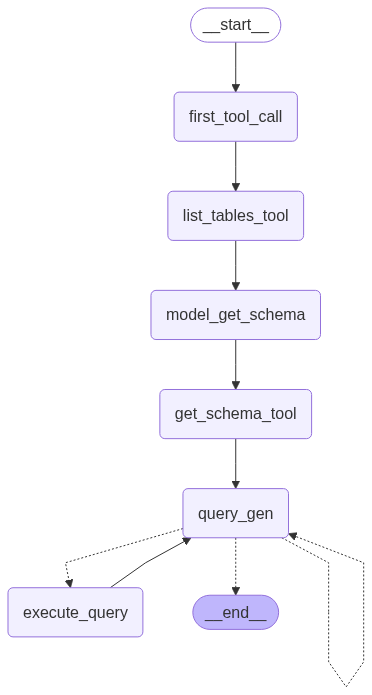

In [125]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

## Run the agent

In [106]:
inputs = {"messages": [("user", "Department Table Inquiry")]}

for chunk in app.stream(inputs, stream_mode="values"):
    for state_key, state_value in chunk.items():
        if state_key == "messages":
            state_value[-1].pretty_print()

================================ Human Message =================================

Department Table Inquiry
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (tool_abcd123)
 Call ID: tool_abcd123
  Args:
================================= Tool Message =================================
Name: sql_db_list_tables

AFTER_SERVICE, AREA_CD, AS_CD, BILL_OF_MATERIAL, CUSTOMER, DAY, DEPARTMENT, EMPLOYEE, EMP_FAMILY, FAMILY_CD, HOUSE_CD, INVENTORY, JOB_DUTY_CD, JOB_POSITION, MAJOR_CD, MATERIAL_IN_OUT, MEDICAL_INSURANCE, MONTH_PRODUCT_IN_OUT, NATIONAL_PENSION, OVERTIME, PART, PRODUCT, PRODUCT_IN_OUT_AMOUNT_PRICE, RELIGION_CD, SALARY, SALARY_DETAIL, SCHOOL_CD, VACATION, VENDOR, WORK_CD, ZIP_CD
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (call_FEb8QfWSospM0ebOQSdoazU4)
 Call ID: call_FEb8QfWSospM0ebOQSdoazU4
  Args:
    table_names: DEPARTMENT
===============================

In [108]:
inputs = {"messages": [("user", "Inquire a person whose rank is G1 among the employees.")]}

for chunk in app.stream(inputs, stream_mode="values"):
    for state_key, state_value in chunk.items():
        if state_key == "messages":
            state_value[-1].pretty_print()

================================ Human Message =================================

Inquire a person whose rank is G1 among the employees.
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (tool_abcd123)
 Call ID: tool_abcd123
  Args:
================================= Tool Message =================================
Name: sql_db_list_tables

AFTER_SERVICE, AREA_CD, AS_CD, BILL_OF_MATERIAL, CUSTOMER, DAY, DEPARTMENT, EMPLOYEE, EMP_FAMILY, FAMILY_CD, HOUSE_CD, INVENTORY, JOB_DUTY_CD, JOB_POSITION, MAJOR_CD, MATERIAL_IN_OUT, MEDICAL_INSURANCE, MONTH_PRODUCT_IN_OUT, NATIONAL_PENSION, OVERTIME, PART, PRODUCT, PRODUCT_IN_OUT_AMOUNT_PRICE, RELIGION_CD, SALARY, SALARY_DETAIL, SCHOOL_CD, VACATION, VENDOR, WORK_CD, ZIP_CD
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (call_u9qcRedSQbktnonhVxmzoMbs)
 Call ID: call_u9qcRedSQbktnonhVxmzoMbs
  Args:
    table_names: EMPLOYEE
===

In [110]:
inputs = {"messages": [("user", "Look up someone whose rank is higher than G1.")]}

for chunk in app.stream(inputs, stream_mode="values"):
    for state_key, state_value in chunk.items():
        if state_key == "messages":
            state_value[-1].pretty_print()

================================ Human Message =================================

Look up someone whose rank is higher than G1.
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (tool_abcd123)
 Call ID: tool_abcd123
  Args:
================================= Tool Message =================================
Name: sql_db_list_tables

AFTER_SERVICE, AREA_CD, AS_CD, BILL_OF_MATERIAL, CUSTOMER, DAY, DEPARTMENT, EMPLOYEE, EMP_FAMILY, FAMILY_CD, HOUSE_CD, INVENTORY, JOB_DUTY_CD, JOB_POSITION, MAJOR_CD, MATERIAL_IN_OUT, MEDICAL_INSURANCE, MONTH_PRODUCT_IN_OUT, NATIONAL_PENSION, OVERTIME, PART, PRODUCT, PRODUCT_IN_OUT_AMOUNT_PRICE, RELIGION_CD, SALARY, SALARY_DETAIL, SCHOOL_CD, VACATION, VENDOR, WORK_CD, ZIP_CD
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (call_pGzeJUD8AtkXD0Ks9asBcrap)
 Call ID: call_pGzeJUD8AtkXD0Ks9asBcrap
  Args:
    table_names: EMPLOYEE
============

In [127]:
inputs = {"messages": [("user", "Check the zip code of '경기도 군포시 궁내동'.")]}

for chunk in app.stream(inputs, stream_mode="values"):
    for state_key, state_value in chunk.items():
        if state_key == "messages":
            state_value[-1].pretty_print()

================================ Human Message =================================

Check the zip code of '경기도 군포시 궁내동'.
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (tool_abcd123)
 Call ID: tool_abcd123
  Args:
================================= Tool Message =================================
Name: sql_db_list_tables

AFTER_SERVICE, AREA_CD, AS_CD, BILL_OF_MATERIAL, CUSTOMER, DAY, DEPARTMENT, EMPLOYEE, EMP_FAMILY, FAMILY_CD, HOUSE_CD, INVENTORY, JOB_DUTY_CD, JOB_POSITION, MAJOR_CD, MATERIAL_IN_OUT, MEDICAL_INSURANCE, MONTH_PRODUCT_IN_OUT, NATIONAL_PENSION, OVERTIME, PART, PRODUCT, PRODUCT_IN_OUT_AMOUNT_PRICE, RELIGION_CD, SALARY, SALARY_DETAIL, SCHOOL_CD, VACATION, VENDOR, WORK_CD, ZIP_CD
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (call_Ob3CyWrPy7Ktv8bKOQXoS7Qt)
 Call ID: call_Ob3CyWrPy7Ktv8bKOQXoS7Qt
  Args:
    table_names: ZIP_CD
=======================

In [133]:
inputs = {"messages": [("user", """The employee table inquires about the number of '사번', '성명', '직급', '부서', 학력'
I only look up people who joined the company after 1998 and whose address is '서울'.""")]}

for chunk in app.stream(inputs, stream_mode="values"):
    for state_key, state_value in chunk.items():
        if state_key == "messages":
            state_value[-1].pretty_print()

================================ Human Message =================================

The employee table inquires about the number of '사번', '성명', '직급', '부서', 학력'
I only look up people who joined the company after 1998 and whose address is '서울'.
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (tool_abcd123)
 Call ID: tool_abcd123
  Args:
================================= Tool Message =================================
Name: sql_db_list_tables

AFTER_SERVICE, AREA_CD, AS_CD, BILL_OF_MATERIAL, CUSTOMER, DAY, DEPARTMENT, EMPLOYEE, EMP_FAMILY, FAMILY_CD, HOUSE_CD, INVENTORY, JOB_DUTY_CD, JOB_POSITION, MAJOR_CD, MATERIAL_IN_OUT, MEDICAL_INSURANCE, MONTH_PRODUCT_IN_OUT, NATIONAL_PENSION, OVERTIME, PART, PRODUCT, PRODUCT_IN_OUT_AMOUNT_PRICE, RELIGION_CD, SALARY, SALARY_DETAIL, SCHOOL_CD, VACATION, VENDOR, WORK_CD, ZIP_CD
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (call

## *** 아래는 오라클 SQL 관련 참고 자료 ***

In [ ]:
import cx_Oracle
import pandas as pd

dsn = cx_Oracle.makedsn("localhost", 1521, "xe")  # db접속 정보
db = cx_Oracle.connect("scott", "1234", dsn)  # db 접속 유저정보
cursor = db.cursor()  # DB에서 불러온 결과 데이터를 담을 메모리확보

cursor.execute(""" select  * from emp """)  # SQL 수행
row = cursor.fetchall()  # SQL로 불러온 데이터를 ROW에 담고
emp = pd.DataFrame(
    row, columns=["EMPNO", "ENAME", "JOB", "MGR", "HIREDATE", "SAL", "COMM", "DEPTNO"]
)

# 동기화를 위해 원본 백업
emp_orig = emp.copy()
emp_orig

In [ ]:
from langchain_openai import ChatOpenAI
from langchain.agents import initialize_agent, Tool
from langchain_experimental.tools import PythonAstREPLTool

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

py_tool = PythonAstREPLTool()
py_tool.locals["emp"] = emp
py_tool.locals["pd"] = (
    pd  # pandas 모듈을 에이전트 코드에서 바로 pd로 사용할 수 있게 등록
)


def run_pandas_code(code: str) -> str:
    """
    emp DataFrame을 변형/조회하는 판다스 코드 실행.
    사용 예:
      emp = emp[emp["SAL"] > 2000]
      emp.loc[emp["DEPTNO"]==10, "SAL"] *= 1.1
      result = emp.head()  # 반환용
    """
    try:
        out = py_tool.invoke({"query": code})
        return str(out)
    except Exception as e:
        return f"[ERROR] {e}"


pandas_tool = Tool(
    name="pandas_df_editor",
    func=run_pandas_code,
    description=(
        "Execute pandas code that edits or queries the global DataFrame 'emp'. "
        "Always end your code by setting a variable named 'result' to what should be printed. "
        "Available names: emp (DataFrame), pd (pandas)."
    ),
)
agent = initialize_agent(
    tools=[pandas_tool],
    llm=llm,
    agent="zero-shot-react-description",
    verbose=True,
)

In [ ]:
prompt = """
EMP 데이터를 다룬다.
1) SAL이 2000 초과인 행만 남겨라.
2) DEPTNO==10 인 행은 SAL을 10% 인상해라.
3) 컬럼 SAL을 반올림(정수) 처리해라.
마지막에 result = emp.head(10) 으로 결과 미리보기 설정하라.
"""
print(agent.run(prompt))

# 이후 emp DataFrame이 수정됨 (emp 변수를 그대로 사용)
emp.head()

In [ ]:
import datetime as dt


def sync_emp_to_oracle(
    emp_new: pd.DataFrame, emp_old: pd.DataFrame, cursor, commit=True
):
    """
    emp_old -> emp_new 변경분을 Oracle(SCOTT.EMP)에 반영.
    기본키: EMPNO
    """
    # 컬럼 정리 & 타입 캐스팅 (DATE 열 주의)
    cols = ["EMPNO", "ENAME", "JOB", "MGR", "HIREDATE", "SAL", "COMM", "DEPTNO"]
    emp_new = emp_new[cols].copy()
    emp_old = emp_old[cols].copy()

    # HIREDATE를 파이썬 datetime.date 로 정규화 (cx_Oracle 바인딩 호환)
    def _to_date(val):
        if pd.isna(val):
            return None
        if isinstance(val, dt.datetime):
            return val.date()
        if isinstance(val, dt.date):
            return val
        # 문자열 등일 때 파서 (필요 시 포맷 수정)
        try:
            return pd.to_datetime(val).date()
        except Exception:
            return None

    emp_new["HIREDATE"] = emp_new["HIREDATE"].apply(_to_date)
    emp_old["HIREDATE"] = emp_old["HIREDATE"].apply(_to_date)

    # 키 기준 병합
    key = "EMPNO"
    old_keys = set(emp_old[key].tolist())
    new_keys = set(emp_new[key].tolist())

    to_insert_keys = list(new_keys - old_keys)
    to_delete_keys = list(old_keys - new_keys)
    common_keys = list(new_keys & old_keys)

    # INSERT
    inserts = emp_new[emp_new[key].isin(to_insert_keys)]
    if not inserts.empty:
        cursor.executemany(
            """
            INSERT INTO SCOTT.EMP
            (EMPNO, ENAME, JOB, MGR, HIREDATE, SAL, COMM, DEPTNO)
            VALUES (:1,:2,:3,:4,:5,:6,:7,:8)
            """,
            [tuple(x) for x in inserts.itertuples(index=False, name=None)],
        )
        print(f"[SYNC] INSERT {len(inserts)} rows")

    # UPDATE (공통키 중 값이 달라진 행만)
    if common_keys:
        common_new = emp_new[emp_new[key].isin(common_keys)].set_index(key)
        common_old = emp_old[emp_old[key].isin(common_keys)].set_index(key)
        # 달라진 행만 골라내기
        changed_keys = []
        for k in common_keys:
            if not common_new.loc[k].equals(common_old.loc[k]):
                changed_keys.append(k)

        updates = emp_new[emp_new[key].isin(changed_keys)]
        if not updates.empty:
            # EMPNO 조건으로 나머지 컬럼 업데이트
            cursor.executemany(
                """
                UPDATE SCOTT.EMP
                SET ENAME=:1, JOB=:2, MGR=:3, HIREDATE=:4, SAL=:5, COMM=:6, DEPTNO=:7
                WHERE EMPNO=:8
                """,
                [
                    (
                        row["ENAME"],
                        row["JOB"],
                        row["MGR"],
                        row["HIREDATE"],
                        row["SAL"],
                        row["COMM"],
                        row["DEPTNO"],
                        row["EMPNO"],
                    )
                    for _, row in updates.iterrows()
                ],
            )
            print(f"[SYNC] UPDATE {len(updates)} rows")

    # DELETE
    if to_delete_keys:
        cursor.executemany(
            "DELETE FROM SCOTT.EMP WHERE EMPNO=:1", [(k,) for k in to_delete_keys]
        )
        print(f"[SYNC] DELETE {len(to_delete_keys)} rows")

    if commit:
        cursor.connection.commit()
        print("[SYNC] COMMIT")

In [ ]:
sync_emp_to_oracle(emp_new=emp, emp_old=emp_orig, cursor=cursor)
# 동기화 후, 다음 번 작업 대비 원본 갱신
emp_orig = emp.copy()

In [ ]:
import cx_Oracle
import pandas as pd

dsn = cx_Oracle.makedsn("localhost", 1521, "xe")  # db접속 정보
db = cx_Oracle.connect("scott", "1234", dsn)  # db 접속 유저정보
cursor = db.cursor()  # DB에서 불러온 결과 데이터를 담을 메모리확보

cursor.execute(""" select  * from emp """)  # SQL 수행
row = cursor.fetchall()  # SQL로 불러온 데이터를 ROW에 담고
df = pd.DataFrame(
    row, columns=["EMPNO", "ENAME", "JOB", "MGR", "HIREDATE", "SAL", "COMM", "DEPTNO"]
)

# 동기화를 위해 원본 백업
df_orig = df.copy()
df_orig

In [ ]:
from langchain_experimental.tools import PythonAstREPLTool

# 파이썬 코드를 실행하는 도구를 생성합니다.
python_tool = PythonAstREPLTool()
python_tool.locals["df"] = df


# 도구 호출 시 실행되는 콜백 함수입니다.
def tool_callback(tool) -> None:  # 도구가 호출될 때마다 이 함수가 실행됩니다.
    print(f"<<<<<<< Code >>>>>>")
    if tool_name := tool.get(
        "tool"
    ):  # tool이라는 딕셔너리에서 "tool" 키 값을 꺼냅니다.
        if (
            tool_name == "python_repl_ast"
        ):  # 값이 "python_repl_ast"라면 → 파이썬 실행 요청이라는 뜻이므로 처리합니다.
            tool_input = tool.get("tool_input")
            for (
                k,
                v,
            ) in (
                tool_input.items()
            ):  # tool_input 딕셔너리에서 "query"라는 키에 해당하는 값(v)이 실행할 파이썬 코드 문자열입니다.
                if (
                    k == "query"
                ):  # 그 코드를 출력합니다. (사람이 어떤 코드가 실행되는지 보게끔)
                    print(v)  # Query 를 출력합니다.
                    result = python_tool.invoke({"query": v})
                    print(result)
    print(f"<<<<<<< Code >>>>>>")


# 관찰 결과를 출력하는 콜백 함수입니다.
def observation_callback(observation) -> None:
    print(f"<<<<<<< Message >>>>>>")
    if "observation" in observation:
        print(observation["observation"])
    print(f"<<<<<<< Message >>>>>>")


# 최종 결과를 출력하는 콜백 함수입니다.
def result_callback(result: str) -> None:
    print(f"<<<<<<< 최종 답변 >>>>>>")
    print(result)
    print(f"<<<<<<< 최종 답변 >>>>>>")

In [ ]:
!pip install tabulate

In [ ]:
from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent
from langchain.agents.agent_types import AgentType
from langchain_openai import ChatOpenAI
from langchain_teddynote.messages import AgentStreamParser, AgentCallbacks

agent = create_pandas_dataframe_agent(
    ChatOpenAI(model="gpt-4o", temperature=0),
    df,  # 두 개이상의 등록된 데이터가 있으면 [df1, df2] 이런 형태로 입력
    verbose=False,
    agent_type="tool-calling",
    allow_dangerous_code=True,
    prefix="You are a professional data analyst and expert in Pandas. "  # 세부적인 요구사항
    "You must use Pandas DataFrame(`df`) to answer user's request. "
    "\n\n[IMPORTANT] DO NOT create or overwrite the `df` variable in your code. \n\n"
    "If you are willing to generate visualization code, please use `plt.show()` at the end of your code. "
    "I prefer seaborn code for visualization, but you can use matplotlib as well."
    "\n\n<Visualization Preference>\n"
    "- `muted` cmap, white background, and no grid for your visualization."
    "\nRecomment to set palette parameter for seaborn plot.",
)

parser_callback = AgentCallbacks(tool_callback, observation_callback, result_callback)
stream_parser = AgentStreamParser(parser_callback)

In [ ]:
def ask(query):
    # 질의에 대한 답변을 출력합니다.
    response = agent.stream({"input": query})

    for step in response:
        stream_parser.process_agent_steps(step)

In [ ]:
# 질의에 대한 답변을 출력합니다.
response = agent.stream(
    {
        "input": """
EMP 데이터를 다룬다.
1) SAL이 2000 초과인 행만 남겨라.
2) DEPTNO==10 인 행은 SAL을 10% 인상해라.
3) 컬럼 SAL을 반올림(정수) 처리해라.
마지막에 result = emp.head(10) 으로 결과 미리보기 설정하라."""
    }
)

for step in response:
    stream_parser.process_agent_steps(step)